In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 10

In [4]:
# transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])
# Load data
train_ds = datasets.CIFAR10(
    root ="./data",
    train=True,
    download=True,
    transform= transform
)
test_ds = datasets.CIFAR10(
    root ="./data",
    train=False,
    download=True,
    transform= transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 170M/170M [23:55<00:00, 119kB/s]


In [5]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [6]:
classes = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

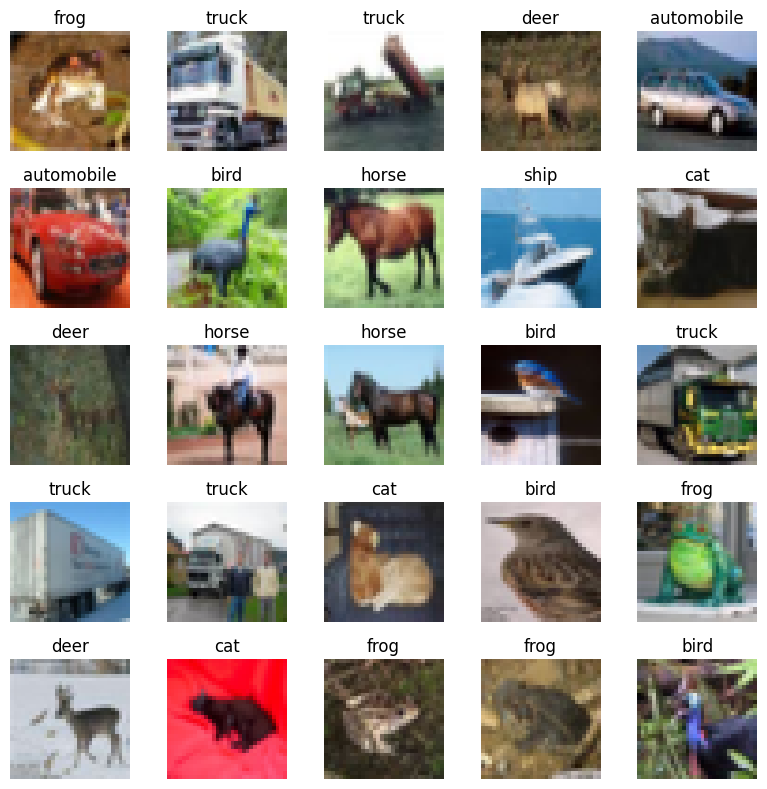

In [7]:
# visualize data

# undo the normalization
mean = torch.tensor([0.5,0.5,0.5]).view(3, 1, 1)
std = torch.tensor([0.5,0.5,0.5]).view(3, 1, 1)

fig, axes = plt.subplots(5,5, figsize=(8, 8))
for i, (image, label) in enumerate(train_ds):
    if i==25:
        break
    image = image * std + mean
    image = image.clamp(0, 1)

    row = i//5
    col = i%5
    axes[row, col].imshow(image.permute(1,2,0))
    axes[row, col].set_title(classes[label])
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

In [8]:
# CNN model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            # Input: (3, 32, 32)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            # Output: 128 x 4 x 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,len(classes))
        )
    def forward(self,x):
        x = self.feature(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print(model)

CNN(
  (feature): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [9]:
# Loss and optimizer
criteration = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [10]:
# Training
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # forward pass
        outputs = model(images)
        loss = criteration(outputs, labels)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss+= loss
    print(f"Epoch:[{epoch+1}]/[{epochs}]    Loss: {running_loss/len(train_ds):.4f} ")

Epoch:[1]/[10]    Loss: 0.0228 
Epoch:[2]/[10]    Loss: 0.0165 
Epoch:[3]/[10]    Loss: 0.0135 
Epoch:[4]/[10]    Loss: 0.0118 
Epoch:[5]/[10]    Loss: 0.0102 
Epoch:[6]/[10]    Loss: 0.0090 
Epoch:[7]/[10]    Loss: 0.0080 
Epoch:[8]/[10]    Loss: 0.0071 
Epoch:[9]/[10]    Loss: 0.0063 
Epoch:[10]/[10]    Loss: 0.0057 


In [11]:
# Testing
model.eval()
total = 0
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted==labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 76.97%


In [12]:
# save model
torch.save(model.state_dict(),"cifar10_cnn.pth")